# Baseline Model - Titanic Classification

A simple ML pipeline demonstrating the essential components for building a predictive model.

## 1.

### Setup and Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

RANDOM_SEED = 42

## 2.

### Load Data

In [4]:
# Load Titanic dataset from seaborn's GitHub repository
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
df = pd.read_csv(url)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 3.

### Basic EDA

In [5]:
# Data types
print("Data types:")
print(df.dtypes)

Data types:
survived         int64
pclass           int64
sex             object
age            float64
sibsp            int64
parch            int64
fare           float64
embarked        object
class           object
who             object
adult_male        bool
deck            object
embark_town     object
alive           object
alone             bool
dtype: object


In [6]:
print("Missing values:")
print((nulls := df.isnull().sum())[nulls > 0])

Missing values:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64


In [7]:
print("Data description:")
print(df.describe().T)

Data description:
          count       mean        std   min      25%      50%   75%       max
survived  891.0   0.383838   0.486592  0.00   0.0000   0.0000   1.0    1.0000
pclass    891.0   2.308642   0.836071  1.00   2.0000   3.0000   3.0    3.0000
age       714.0  29.699118  14.526497  0.42  20.1250  28.0000  38.0   80.0000
sibsp     891.0   0.523008   1.102743  0.00   0.0000   0.0000   1.0    8.0000
parch     891.0   0.381594   0.806057  0.00   0.0000   0.0000   0.0    6.0000
fare      891.0  32.204208  49.693429  0.00   7.9104  14.4542  31.0  512.3292


In [8]:
# Target distribution
print("Target distribution:")
print(df["survived"].value_counts())
print(f"\nSurvival rate: {df['survived'].mean():.2%}")

Target distribution:
survived
0    549
1    342
Name: count, dtype: int64

Survival rate: 38.38%


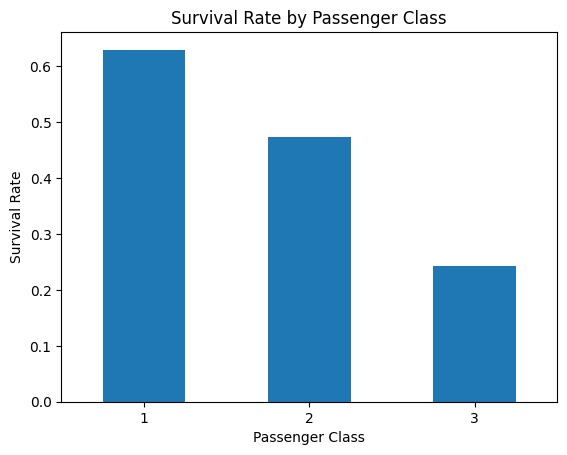

In [9]:
# Survival rate by passenger class
survival_by_class = df.groupby("pclass")["survived"].mean()
survival_by_class.plot(kind="bar", title="Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.xticks(rotation=0)
plt.show()

## 4.

### Preprocessing

In [10]:
# Handle missing values
df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

# Encode categorical variables
df["sex"] = df["sex"].map({"male": 0, "female": 1})
df["embarked"] = df["embarked"].map({"S": 0, "C": 1, "Q": 2})

# Drop remaining columns we won't use
cols_to_drop = ["alive", "who", "adult_male", "deck", "embark_town", "class", "alone"]
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

print("Preprocessed data:")
df.head().T

Preprocessed data:


,0,1,2,3,4
survived,0.00,1.0000,1.000,1.0,0.00
pclass,3.00,1.0000,3.000,1.0,3.00
sex,0.00,1.0000,1.000,1.0,0.00
age,22.00,38.0000,26.000,35.0,35.00
sibsp,1.00,1.0000,0.000,1.0,0.00
parch,0.00,0.0000,0.000,0.0,0.00
fare,7.25,71.2833,7.925,53.1,8.05
embarked,0.00,1.0000,0.000,0.0,0.00


In [11]:
# Define features and target
X = df.drop(columns=["survived"])
y = df["survived"]

# Scale numerical features
scaler = StandardScaler()
numerical_cols = ["age", "fare"]
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
X.head()

Features shape: (891, 7)
Target shape: (891,)


,pclass,sex,age,sibsp,parch,fare,embarked
0,3,0,-0.565736,1,0,-0.502445,0
1,1,1,0.663861,1,0,0.786845,1
2,3,1,-0.258337,0,0,-0.488854,0
3,1,1,0.433312,1,0,0.420730,0
4,3,0,0.433312,0,0,-0.486337,0


## 5.

### Train/Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 712 samples
Test set: 179 samples


## 6.

### Model Training

In [14]:
# Train a DummyClassifier as a baseline
# This predicts the most frequent class - any real model should beat this
model = DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED)
model.fit(X_train, y_train)

print("Baseline model trained (DummyClassifier - predicts most frequent class)")

Baseline model trained (DummyClassifier - predicts most frequent class)


## 7.

### Evaluation

#### train set

In [15]:
# Training set performance
y_train_pred = model.predict(X_train)
print("Training Set:")
print(f"  Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"  F1 Score: {f1_score(y_train, y_train_pred, average='weighted'):.4f}")

Training Set:
  Accuracy: 0.6236
  F1 Score: 0.4790


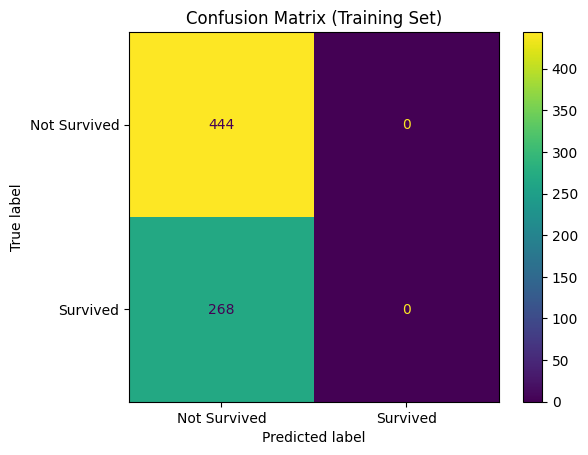

In [16]:
# Confusion matrix (training set)
cm_train = confusion_matrix(y_train, y_train_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=["Not Survived", "Survived"])
disp.plot()
plt.title("Confusion Matrix (Training Set)")
plt.show()

#### test set

In [ ]:
# Test set performance
y_test_pred = model.predict(X_test)
print("Test Set:")
print(f"  Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"  F1 Score: {f1_score(y_test, y_test_pred, average='weighted'):.4f}")
print(f"  Predictions: {len(y_test_pred)} total, distribution: {pd.Series(y_test_pred).value_counts().to_dict()}")

In [ ]:
# Confusion matrix (test set)
cm_test = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=["Not Survived", "Survived"])
disp.plot()
plt.title("Confusion Matrix (Test Set)")
plt.show()